# Agrupamiento Jerárquico. 
# Eurovisión 2016

Disponemos de un archivo csv con la relación de países que participaron con una canción en Eurovisión (Segunda columna del archivo) y los países que votaron en este concurso (Primera columna). Los puntos concedidos a cada canción se encuentran en la columna etiquetada como 'Jury Points'.
Vamos a extraer de este dataset solo el conjunto de paises que actuaron  y votaron (descartando los que votaron pero no actuaron) y caracterizaremos a cada país por un vector que representa sus puntos a cada canción.
Posteriormente aplicaremos el **Agrupamiento Jerárquico** para ver si países con votos similares tienen alguna relación geográfica (o de otro tipo que puedas descubrir) entre sí.

El código de la siguiente ventana, aparte de importar todas las librerías de Python que necesitas, también crea una matriz con todos los vectores de votaciones de todos los países que presentaron una canción (llamado **samples**) y una lista de países llamada **list_of_countries**.
Puedes intentar crear estas dos estructuras tú mism@ usando otras estrategias (el código que presento no tiene por qué ser el más eficiente). Se valorará este esfuerzo por tu parte.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
# Imports necesarios para el agrupamiento jerarquico
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import sys
import pandas as pd

data = pd.read_csv("eurovision-2016.csv") # lee el csv en un panda



datagood = data[['From country', 'To country', 'Jury Points']] #Crea de 'data' un panda con las columnas  'From country', 'To country', 'Jury Points'

countries = data.loc[0:25,['To country']]

#Creación de la lista de paises
list_of_countries = countries['To country'].tolist()

print(list_of_countries)

datadef = datagood.loc[datagood['From country'].isin(list_of_countries)]



#ponemos los valores Nan de la columna 'Jury Points' to 0

datadef['Jury Points'].fillna(0.0, inplace=True)

#Bucle de creación de la matriz 2D con los vectores de puntuaciones de los paises
#Esta matriz sigue el orden de la lista de paises
samples=[]
cont=0
for i in list_of_countries:
  paisframe= datadef.loc[datagood['From country'].isin([i])]


  #Cuidado!! En la siguiente instrucción puede haber un error de incompatibilidad entre versiones
  #En versiones antiguas se usa el método 'as_matrix(). En versiones modernas el método 'to_numpy()'
  y = paisframe['Jury Points'].to_numpy().reshape(1,len(paisframe['Jury Points']))
  samples.insert(cont,y.flatten())
  cont=cont+1

['Belgium', 'Czech Republic', 'The Netherlands', 'Azerbaijan', 'Hungary', 'Italy', 'Israel', 'Bulgaria', 'Sweden', 'Germany', 'France', 'Poland', 'Australia', 'Cyprus', 'Serbia', 'Lithuania', 'Croatia', 'Russia', 'Spain', 'Latvia', 'Ukraine', 'Malta', 'Georgia', 'Austria', 'United Kingdom', 'Armenia']


C:\Users\victo\AppData\Local\Temp\ipykernel_19580\1573519628.py:29: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datadef['Jury Points'].fillna(0.0, inplace=True)
C:\Users\victo\AppData\Local\Temp\ipykernel_19580\1573519628.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datadef['Jury Points'].fillna(0.0, inplace=True)


Ahora vamos a realizar el agrupamiento jeráquico. Como sabes, existen diferentes tipos de Linkage y esto provocará diferentes resultados en el agrupamiento.Vamos a comenzar con el más sencillo que es el Linkage **'single'**.

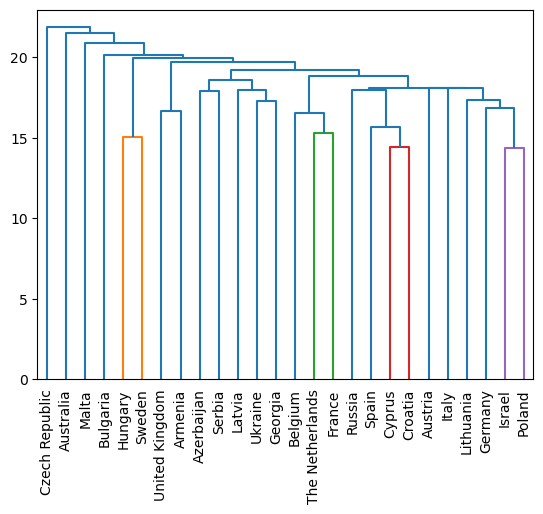

In [17]:
# Calculate the linkage: mergings
mergings = linkage(samples, method='single')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

Fijate en el Dendrograma que se ha creado. Los países se agrupan por puntuaciones. Es decir, cada país tiene asociado un vector de enteros que recoge los puntos que ha dado a cada canción (el mismo orden de canciones para todos los países). El dendrograma va asociando países con puntuaciones similares. Extrae tus conclusiones acerca de los grupos que se van creando a diferentes valores de las distancias (eje Y)

**Respuesta:** (expón tus conclusiones aquí)

Vamos a probar ahora los resultados para los diferentes tipos de distancias que nos permite la implementación de ScyPython de este modo de clustering. Introduce en cada celda el código para obtener el dendrograma correspondiente a cada definición de "Linkage" (distancia entre clusters): 'complete', 'average', 'weighted', 'centroid', 'median', 'ward'. Observa los dendrogramas resultantes y razona cuales de ellos dan unos agrupamientos de países más significativos.

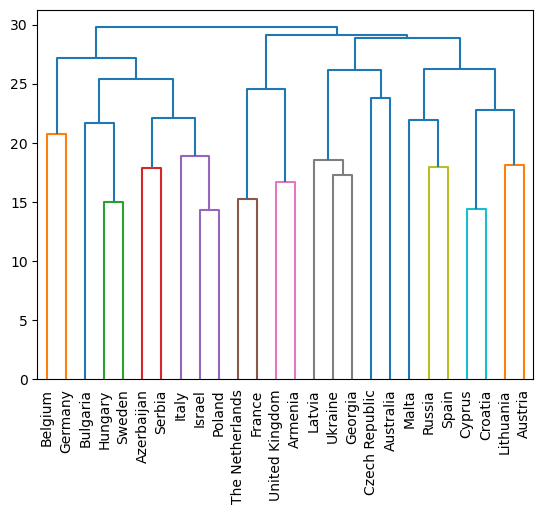

In [3]:
#complete

# Calculate the linkage: mergings
mergings = linkage(samples, method='complete')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

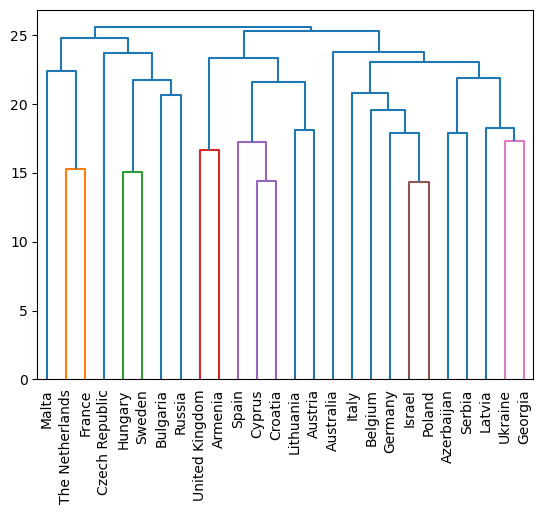

In [4]:
#average

# Calculate the linkage: mergings
mergings = linkage(samples, method='average')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

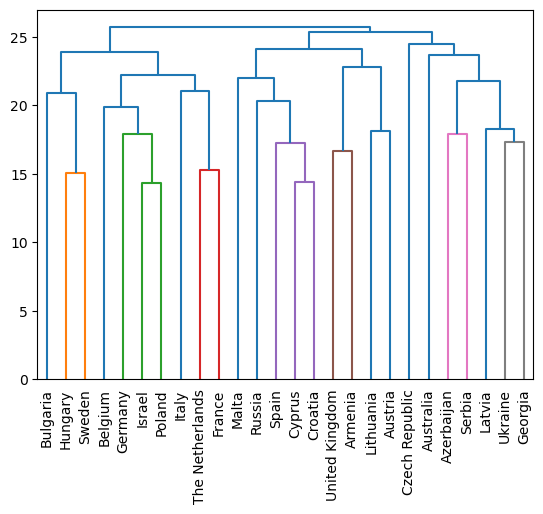

In [29]:
#weighted

# Calculate the linkage: mergings
weighted = linkage(samples, method='weighted')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(weighted, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

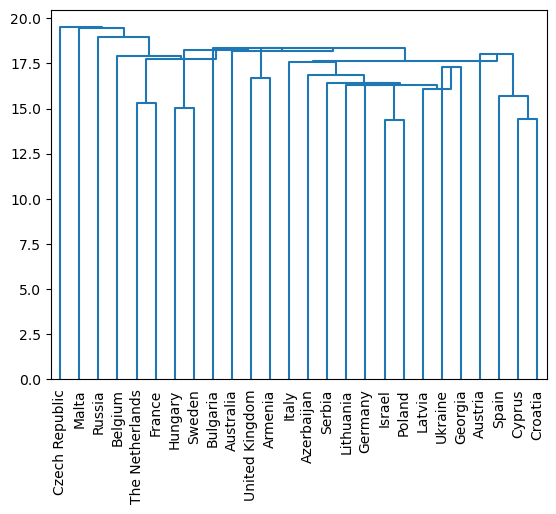

In [6]:
#centroid

# Calculate the linkage: mergings
mergings = linkage(samples, method='centroid')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

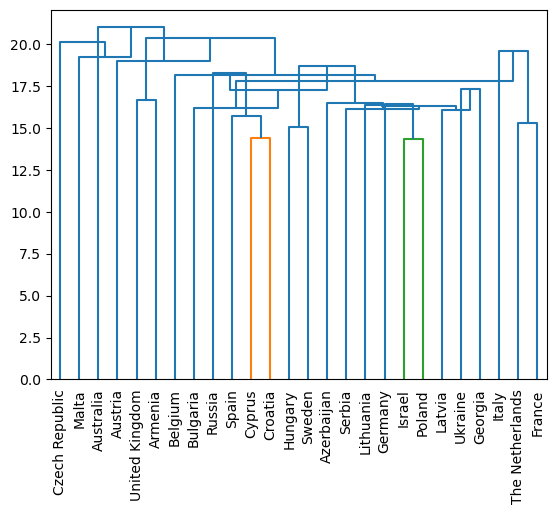

In [7]:
#median

# Calculate the linkage: mergings
mergings = linkage(samples, method='median')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

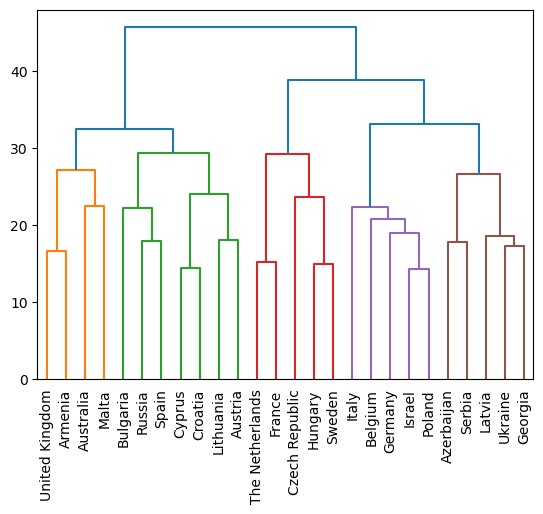

In [24]:
#ward

# Calculate the linkage: mergings
mergings = linkage(samples, method='ward')  #usa el linkage 'single' con los datos de 'samples'

# Plot the dendrogram
dendrogram(mergings, labels=list_of_countries, leaf_rotation=90, leaf_font_size=10)
plt.show()

**Respuesta aqui:**

También podemos pedirle a Python que nos muestre los agrupamientos para una distancia de clusters menor o igual que la de un valor determinado. Esto es equivalente a realizar un corte horizontal en el dendrograma a una altura de dicho valor. Esto lo podemos realizar con el método **'fcluster()'**. Este método etiqueta cada elemento con la etiqueta numérica de un cluster. Así países con la misma etiqueta pertenecen al mismo cluster en esa 'altura' o distancia entre clusters.
**'Importante: '** Fíjate en la forma del dendograma para elegir la distancia. Si eliges una distancia muy pequeña, el corte del dendrograma se producirá cerca de las hojas y por tanto es posible que tengas tantos clusters como elementos.

In [30]:
#labeling clusters con fclusters
distan = int(input("Introduce la distancia a cortar el dendograma:  "))

labels = fcluster(weighted, t=distan, criterion='distance') #usa aqui fcluster con la distncia

print("La etiqueta de pertenencia grupo de cada pais es:")
print(labels)


Introduce la distancia a cortar el dendograma:   23


La etiqueta de pertenencia grupo de cada pais es:
[2 7 2 5 1 2 2 1 1 2 2 2 6 3 5 4 3 3 3 5 5 3 5 4 4 4]


Ahora podemos construir un DataFrame con las etiquetas que nos ha proporcionado el método **'fcluster()'** y la lista de países para ver claramente los clusteres formados con esa distancia de corte del dendrograma.

In [26]:

print("Agrupamos paises por etiquetas para la distancia introducida")

pares = pd.DataFrame({'labels': labels, 'countries': list_of_countries})

print(pares.sort_values('labels'))

Agrupamos paises por etiquetas para la distancia introducida
    labels        countries
12       1        Australia
25       1          Armenia
24       1   United Kingdom
21       1            Malta
16       2          Croatia
7        2         Bulgaria
13       2           Cyprus
15       2        Lithuania
17       2           Russia
18       2            Spain
23       2          Austria
10       3           France
8        3           Sweden
1        3   Czech Republic
4        3          Hungary
2        3  The Netherlands
5        4            Italy
0        4          Belgium
9        4          Germany
11       4           Poland
6        4           Israel
3        5       Azerbaijan
14       5           Serbia
19       5           Latvia
22       5          Georgia
20       5          Ukraine


Una idea de dónde realizar un corte en el dendrograma es considerar el lugar que más hueco tiene entre dos posiciones horizontales sucesivas. Repasa tus dendrogramas obtenidos con todos los linkage e indica para cada uno cuál sería el nivel de corte según este criterio. ¿Hay alguno especialmente claro? Usa con ese fcluster  y utiliza el código de la últma caja anterior para ver los paises ordenados por este agrupamiento. ¿Hay alguna relación entre países?
Escribe tu código y comentarios en dos cajas sucesivas abajo de ésta.

In [31]:
#labeling clusters con fclusters
distan = int(input("Introduce la distancia a cortar el dendograma:  "))

labels = fcluster(mergings, t=distan, criterion='distance') #usa aqui fcluster con la distncia

print("La etiqueta de pertenencia grupo de cada pais es:")
print(labels)


Introduce la distancia a cortar el dendograma:   30


La etiqueta de pertenencia grupo de cada pais es:
[4 3 3 5 3 4 4 2 3 4 3 4 1 2 5 2 2 2 2 5 5 1 5 2 1 1]


In [32]:
print("Agrupamos paises por etiquetas para la distancia introducida")

pares = pd.DataFrame({'labels': labels, 'countries': list_of_countries})

print(pares.sort_values('labels'))

Agrupamos paises por etiquetas para la distancia introducida
    labels        countries
12       1        Australia
25       1          Armenia
24       1   United Kingdom
21       1            Malta
16       2          Croatia
7        2         Bulgaria
13       2           Cyprus
15       2        Lithuania
17       2           Russia
18       2            Spain
23       2          Austria
10       3           France
8        3           Sweden
1        3   Czech Republic
4        3          Hungary
2        3  The Netherlands
5        4            Italy
0        4          Belgium
9        4          Germany
11       4           Poland
6        4           Israel
3        5       Azerbaijan
14       5           Serbia
19       5           Latvia
22       5          Georgia
20       5          Ukraine
